In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Conv1D, MaxPooling1D, Dense, Dropout, Flatten, Concatenate, LSTM, BatchNormalization, SpatialDropout1D, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.losses import Huber
import os
import random
from scipy import stats
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt 
import xgboost as xgb
from scipy import stats
import shap
from Common_Functions import set_global_determinism, evaluate, \
                                ROC_AUC, CNN_LSTM_Explain, feature_importance, \
                                analyse_profit, analyse_profit, \
                                Prepare_Data, Prepare_Data_XGBoost, \
                                best_threshold,CNN_LSTM_Model, CNN_LSTM_Results, \
                                XGBoost_Results, Meta_Model, feature_importance_table


folder = "exported_csvs"

data = {
    os.path.splitext(f)[0]: pd.read_csv(os.path.join(folder, f))
    for f in os.listdir(folder) if f.endswith(".csv")
}

train_idx, val_idx, test_idx = np.array(data['train_indices']).ravel(), np.array(data['val_indices']).ravel() ,np.array(data['test_indices']).ravel()

profit_features = [
    #'back_prices_0_scaled_seq', 
    #'back_volumes_0_scaled_seq', 
    #'back_prices_1_scaled_seq', 
    'back_volumes_1_scaled_seq',
    #'lay_prices_0_scaled_seq', 
    #'lay_volumes_0_scaled_seq', 
    #'lay_prices_1_scaled_seq', 
    'lay_volumes_1_scaled_seq',
    'back_VWAP_scaled_seq',
    'lay_VWAP_scaled_seq',
    'others_back_PVT_seq', 
    'others_lay_PVT_seq', 
    #'back_PVT_seq',
    #'lay_PVT_seq',
    'WOM_seq', 
    #'back_VWAP_log_return_seq', 
    #'lay_VWAP_log_return_seq'
]

back_lay_target_feature = 'back_lay_profit_sign'
lay_back_target_feature = 'lay_back_profit_sign'

back_lay_profit_seq = np.array(data['back_lay_profit'])[test_idx].ravel()
lay_back_profit_seq = np.array(data['lay_back_profit'])[test_idx].ravel()

/opt/anaconda3/envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
np.sum( data['lay_back_profit_sign'] )/ len( data['lay_back_profit_sign'] )

output    0.453145
dtype: float64

In [4]:
back_lay_results = CNN_LSTM_Results(profit_features, back_lay_target_feature)
lay_back_results = CNN_LSTM_Results(profit_features, lay_back_target_feature)
back_lay_XGBoost_results = XGBoost_Results(profit_features, back_lay_target_feature)
lay_back_XGBoost_results = XGBoost_Results(profit_features, lay_back_target_feature)
baseline_back_lay_XGBoost_results = XGBoost_Results(['back_VWAP_log_return_seq'], back_lay_target_feature, 1)
baseline_lay_back_XGBoost_results = XGBoost_Results(['back_VWAP_log_return_seq'], lay_back_target_feature, 1)

869/869 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 1s 492us/step
val_set best precision: 0.5396825396825397
869/869 ━━━━━━━━━━━━━━━━━━━━ 1s 623us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 1s 474us/step
val_set best precision: 0.5288135593220339
Best params: {'max_depth': 6, 'learning_rate': 0.1}, Best PR-AUC: 0.4763
val_set best precision: 0.5254237288135594
Best params: {'max_depth': 4, 'learning_rate': 0.1}, Best PR-AUC: 0.5224
val_set best precision: 0.7169811320754716
Best params: {'max_depth': 7, 'learning_rate': 0.1}, Best PR-AUC: 0.4629
val_set best precision: 0.5942028985507246
Best params: {'max_depth': 5, 'learning_rate': 0.01}, Best PR-AUC: 0.4830
val_set best precision: 0.4935064935064935


In [5]:
print( back_lay_results['metrics'], '\n', lay_back_results['metrics'] )

{'f1_score': 0.07203884688671706, 'precision_score': 0.4920235096557515, 'recall_score': 0.03886457089799708, 'accuracy_score': 0.5830133959397873, 'log_loss': 0.6981097395324803, 'log_loss_ci': (0.6970321830460013, 0.6992001116514144)} 
 {'f1_score': 0.09135435584172583, 'precision_score': 0.5266497461928934, 'recall_score': 0.05001506477854775, 'accuracy_score': 0.5439580168485015, 'log_loss': 0.6901891316536598, 'log_loss_ci': (0.6889980742498111, 0.6913853384857899)}


In [6]:
print( back_lay_XGBoost_results['metrics'], '\n', lay_back_XGBoost_results['metrics'] )

{'f1_score': 0.015517016560177337, 'precision_score': 0.4576923076923077, 'recall_score': 0.007892293407613741, 'accuracy_score': 0.5829305344565667, 'log_loss': 0.6913718488183668, 'log_loss_ci': (0.6909604545794154, 0.6917969207147475)} 
 {'f1_score': 0.01907243973227507, 'precision_score': 0.5590277777777778, 'recall_score': 0.009701717384754444, 'accuracy_score': 0.5425769921281591, 'log_loss': 0.6886834081712953, 'log_loss_ci': (0.6870718673580705, 0.690188588592654)}


In [7]:
print( baseline_back_lay_XGBoost_results['metrics'], '\n', baseline_lay_back_XGBoost_results['metrics'] )

{'f1_score': 0.021105787906254045, 'precision_score': 0.4429347826086957, 'recall_score': 0.010810452314630587, 'accuracy_score': 0.5823781245684297, 'log_loss': 0.6883957332206767, 'log_loss_ci': (0.6875240965350251, 0.6892950125998156)} 
 {'f1_score': 0.020472996823155665, 'precision_score': 0.4317617866004963, 'recall_score': 0.010485085869237722, 'accuracy_score': 0.5401187681259495, 'log_loss': 0.6921041142620923, 'log_loss_ci': (0.6918823338450639, 0.6923252261529664)}


In [8]:
sum(back_lay_results['test_true']) / len(back_lay_results['test_true'])

0.4164618146664825

In [9]:
print('CNN_LSTM:')
print('ideal back_lay profit:', np.sum( back_lay_results['test_true']*back_lay_profit_seq ) )
print('model back_lay profit:', np.sum( back_lay_results['forecast']*back_lay_profit_seq ) )
print('ideal lay_back profit:', np.sum( lay_back_results['test_true']*lay_back_profit_seq ) )
print('model lay_back profit:', np.sum( lay_back_results['forecast']*lay_back_profit_seq ) )

CNN_LSTM:
ideal back_lay profit: 114.21372991175775
model back_lay profit: -6.7557478949848875
ideal lay_back profit: 116.54737495355877
model lay_back profit: -11.173198988920579


In [10]:
print('XGBoost:')
print('ideal back_lay profit:', np.sum( back_lay_XGBoost_results['test_true']*back_lay_profit_seq ) )
print('model back_lay profit:', np.sum( back_lay_XGBoost_results['forecast']*back_lay_profit_seq ) )
print('ideal lay_back profit:', np.sum( lay_back_XGBoost_results['test_true']*lay_back_profit_seq ) )
print('model lay_back profit:', np.sum( lay_back_XGBoost_results['forecast']*lay_back_profit_seq ) )

XGBoost:
ideal back_lay profit: 114.21372991175775
model back_lay profit: -2.054219186087593
ideal lay_back profit: 116.54737495355877
model lay_back profit: -1.1734788966879737


In [11]:
back_lay_meta_results = Meta_Model(back_lay_results, back_lay_XGBoost_results, max_depth=3)
lay_back_meta_results = Meta_Model(lay_back_results, lay_back_XGBoost_results, max_depth=3)

val_set best precision: 0.6021505376344086
val_set best precision: 0.5917874396135265


In [12]:
print( back_lay_meta_results['metrics'], '\n', lay_back_meta_results['metrics'] )

{'f1_score': 0.02613026324299851, 'precision_score': 0.5274151436031331, 'recall_score': 0.013397002254940974, 'accuracy_score': 0.5841182157160613, 'log_loss': 0.6748312842926706, 'log_loss_ci': (0.6728564463249557, 0.6768243781817995)} 
 {'f1_score': 0.13662098523731414, 'precision_score': 0.5603298611111112, 'recall_score': 0.07779451642060861, 'accuracy_score': 0.5493163927634305, 'log_loss': 0.6833365083876285, 'log_loss_ci': (0.681738423724557, 0.6849815715360821)}


In [13]:
print('Meta:')
print('ideal back_lay profit:', np.sum( back_lay_meta_results['test_true']*back_lay_profit_seq ) )
print('model back_lay profit:', np.sum( back_lay_meta_results['forecast']*back_lay_profit_seq ) )
print('ideal lay_back profit:', np.sum( lay_back_meta_results['test_true']*lay_back_profit_seq ) )
print('model lay_back profit:', np.sum( lay_back_meta_results['forecast']*lay_back_profit_seq ) )

Meta:
ideal back_lay profit: 114.21372991175775
model back_lay profit: -3.2951619275202124
ideal lay_back profit: 116.54737495355877
model lay_back profit: -12.743165221161956


In [14]:
print( analyse_profit(back_lay_results['forecast']*back_lay_profit_seq ),
       analyse_profit(lay_back_results['forecast']*lay_back_profit_seq),
       analyse_profit(back_lay_XGBoost_results['forecast']*back_lay_profit_seq),
       analyse_profit(lay_back_XGBoost_results['forecast']*lay_back_profit_seq),
       analyse_profit(baseline_back_lay_XGBoost_results['forecast']*back_lay_profit_seq),
       analyse_profit(baseline_lay_back_XGBoost_results['forecast']*lay_back_profit_seq),
       analyse_profit(back_lay_meta_results['forecast']*back_lay_profit_seq),
       analyse_profit(lay_back_meta_results['forecast']*lay_back_profit_seq))

{'total_return': -6.755747894984886, 'average_return_per_bet': -0.005672332405528871, 'positive_rate': 0.4920235096557515, 'confidence_interval_95': (-0.006597573791560888, -0.004747091019496855), 'number_of_bets': 1191, 'total_observations': 36205, 'bets_ratio': 0.03289600883855821} {'total_return': -11.17319898892058, 'average_return_per_bet': -0.007089593267081587, 'positive_rate': 0.5266497461928934, 'confidence_interval_95': (-0.008218093522580454, -0.005961093011582721), 'number_of_bets': 1576, 'total_observations': 36205, 'bets_ratio': 0.04352989918519542} {'total_return': -2.054219186087593, 'average_return_per_bet': -0.007900843023413819, 'positive_rate': 0.4576923076923077, 'confidence_interval_95': (-0.01084120649602461, -0.0049604795508030285), 'number_of_bets': 260, 'total_observations': 36205, 'bets_ratio': 0.00718132854578097} {'total_return': -1.1734788966879734, 'average_return_per_bet': -0.004074579502388796, 'positive_rate': 0.5590277777777778, 'confidence_interval_9

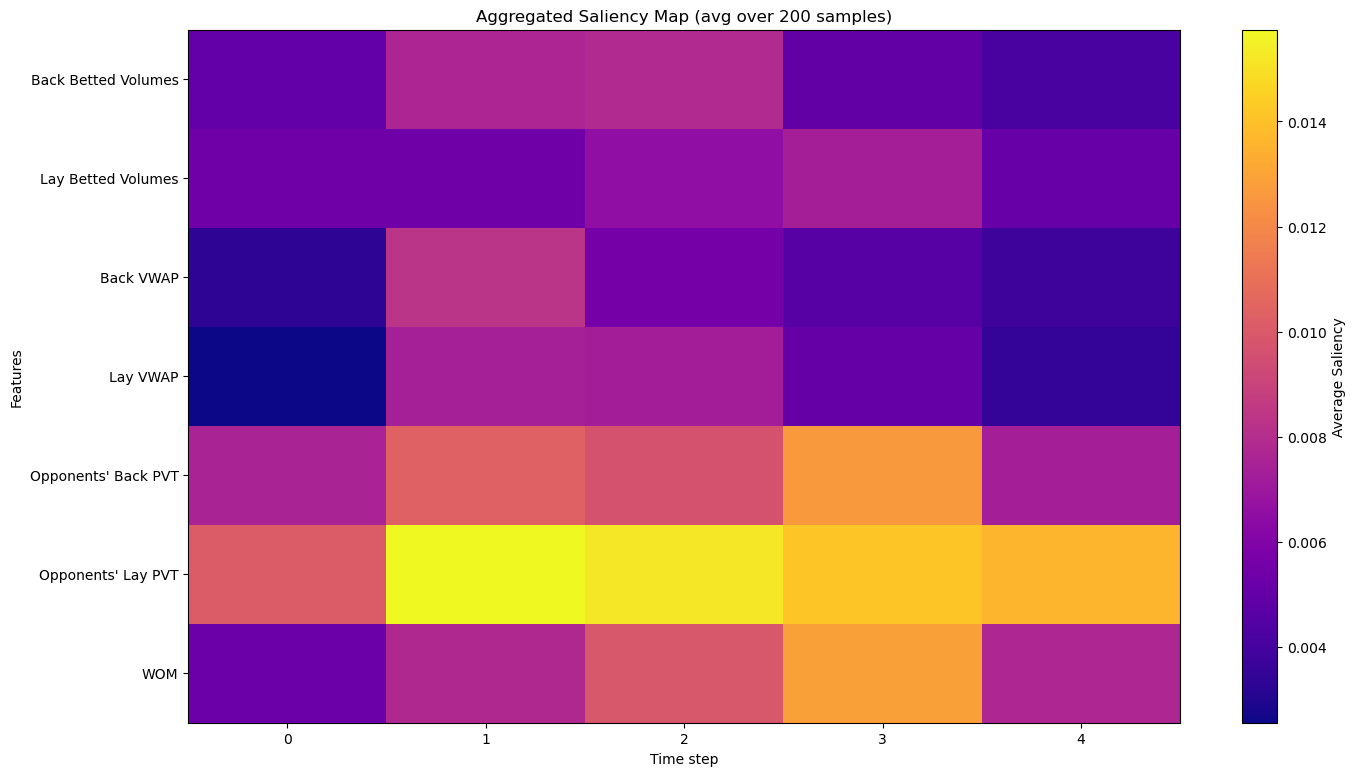

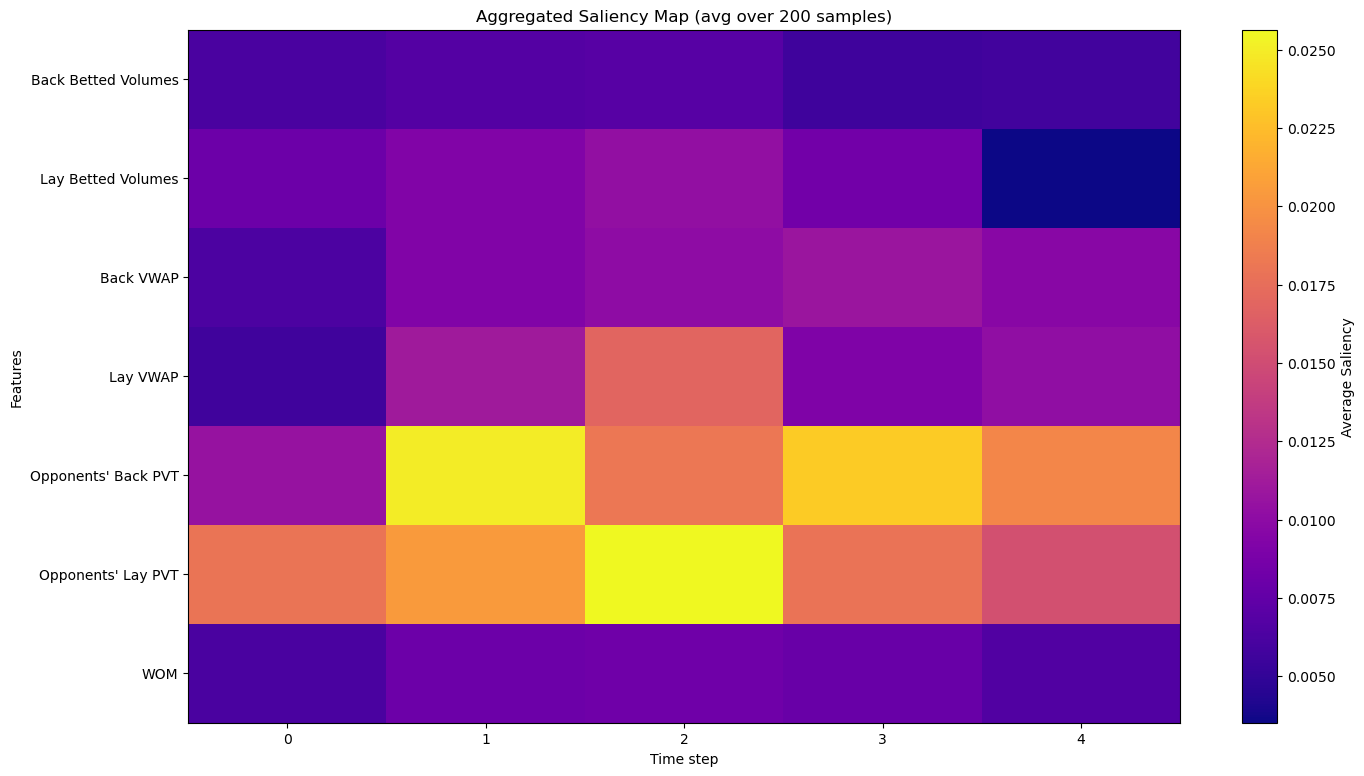

In [15]:
CNN_LSTM_Explain(back_lay_results['model'], back_lay_results['X_test'],'task2_bl',['Back Betted Volumes',
                                                                                                'Lay Betted Volumes',
                                                                                                'Back VWAP',
                                                                                                'Lay VWAP',
                                                                                                'Opponents\' Back PVT', 
                                                                                                'Opponents\' Lay PVT', 'WOM'])
CNN_LSTM_Explain(lay_back_results['model'], lay_back_results['X_test'], 'task2_lb',['Back Betted Volumes',
                                                                                                'Lay Betted Volumes',
                                                                                                'Back VWAP',
                                                                                                'Lay VWAP',
                                                                                                'Opponents\' Back PVT', 
                                                                                                'Opponents\' Lay PVT', 'WOM'])

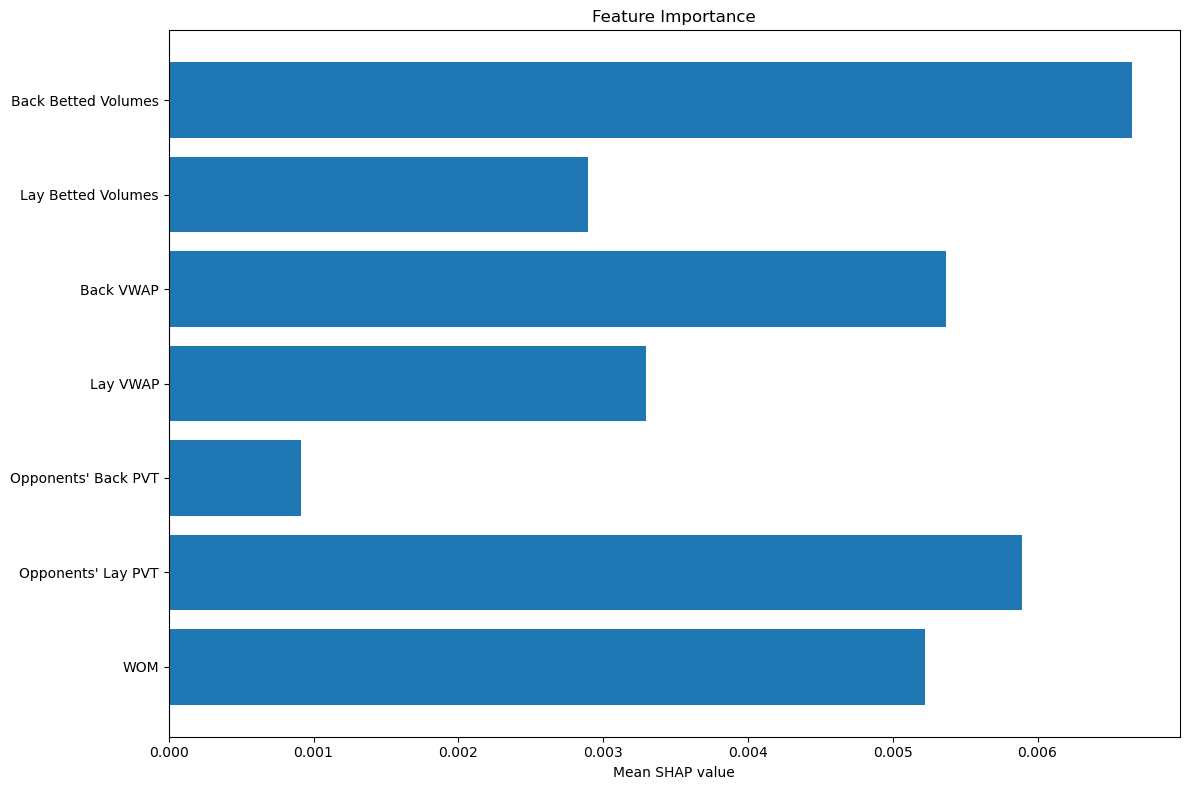

"\\begin{table}[h!]\n\\begin{tabular}{lr}\n\\toprule\nfeature_names & feature_importance (%) \\\\\n\\midrule\nBack Betted Volumes & 22.0 \\\\\nLay Betted Volumes & 9.6 \\\\\nBack VWAP & 17.8 \\\\\nLay VWAP & 10.9 \\\\\nOpponents' Back PVT & 3.0 \\\\\nOpponents' Lay PVT & 19.5 \\\\\nWOM & 17.3 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [16]:
feature_importance_table(back_lay_XGBoost_results['model'], back_lay_XGBoost_results['X_test'],['Back Betted Volumes',
                                                                                                'Lay Betted Volumes',
                                                                                                'Back VWAP',
                                                                                                'Lay VWAP',
                                                                                                'Opponents\' Back PVT', 
                                                                                                'Opponents\' Lay PVT', 'WOM'])

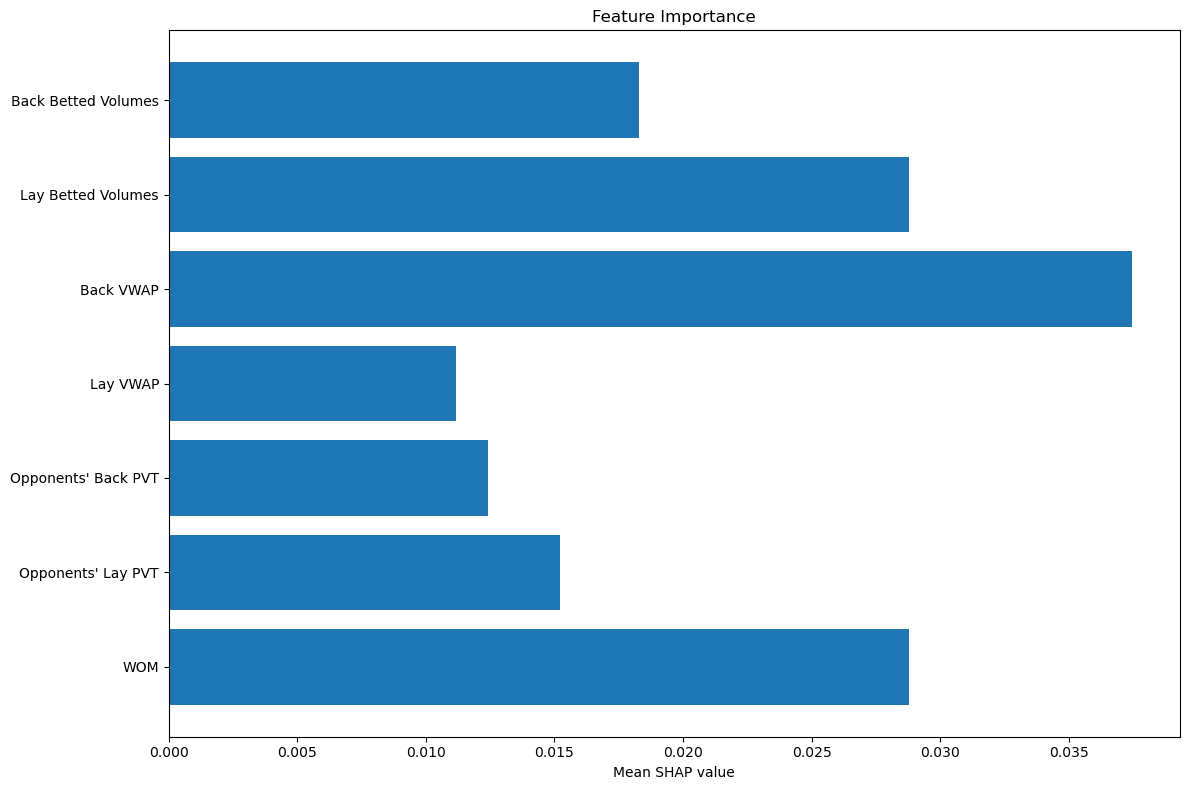

"\\begin{table}[h!]\n\\begin{tabular}{lr}\n\\toprule\nfeature_names & feature_importance (%) \\\\\n\\midrule\nBack Betted Volumes & 12.0 \\\\\nLay Betted Volumes & 18.9 \\\\\nBack VWAP & 24.6 \\\\\nLay VWAP & 7.3 \\\\\nOpponents' Back PVT & 8.2 \\\\\nOpponents' Lay PVT & 10.0 \\\\\nWOM & 18.9 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [17]:
feature_importance_table(lay_back_XGBoost_results['model'], lay_back_XGBoost_results['X_test'],['Back Betted Volumes',
                                                                                                'Lay Betted Volumes',
                                                                                                'Back VWAP',
                                                                                                'Lay VWAP',
                                                                                                'Opponents\' Back PVT', 
                                                                                                'Opponents\' Lay PVT', 'WOM'])